In [1]:
%matplotlib inline
from collections import OrderedDict, defaultdict
import importlib.resources
import os.path
import pathlib
import warnings

import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.wcs import WCS
from scipy.special import erf

import scopesim as sim
from scopesim.utils import from_currsys
import scopesim_templates as sim_tp

In [2]:
def configure_path_and_logging(irdb_path=None, level="debug"):
    """Configure ScopeSim to find the local IRDB package once."""
    try:
        resolved_irdb_path = pathlib.Path(importlib.resources.files("irdb")).parent
    except ModuleNotFoundError:
        if irdb_path is None:
            irdb_path = "/Users/jibailey/src/irdb"
        resolved_irdb_path = pathlib.Path(irdb_path).expanduser()
        if not resolved_irdb_path.exists():
            raise FileNotFoundError(resolved_irdb_path)

    resolved_irdb_path = str(resolved_irdb_path)
    sim.rc.__config__["!SIM.file.local_packages_path"] = resolved_irdb_path

    search_path = sim.rc.__config__["!SIM.file.search_path"]
    if resolved_irdb_path not in search_path:
        search_path.append(resolved_irdb_path)

    sim.utils.set_console_log_level(level)
    return resolved_irdb_path


def zshooter_package_dir(irdb_path):
    return pathlib.Path(irdb_path).expanduser().resolve() / "ZShooter_v2"


def validation_work_dir(irdb_path=None, name="validation_outputs"):
    """Return a repo-local output directory, avoiding accidental writes into IRDB."""
    cwd = pathlib.Path.cwd().resolve()
    if irdb_path is not None:
        package_dir = zshooter_package_dir(irdb_path)
        if cwd == package_dir or package_dir in cwd.parents:
            cwd = pathlib.Path("/Users/jibailey/src/zs-scopesim").resolve()
    output_dir = cwd / name
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir


def disable_scopesim_top_level_catch():
    """Unwrap ScopeSim's bug-report decorator while debugging in notebooks."""
    import inspect
    import scopesim
    import scopesim.optics.optical_train as optical_train

    cls = optical_train.OpticalTrain
    for method_name in ("__init__", "observe"):
        method = getattr(cls, method_name)
        unwrapped_method = inspect.unwrap(method)
        if unwrapped_method is not method:
            setattr(cls, method_name, unwrapped_method)
    scopesim.OpticalTrain = cls


def warning_prevent_sync_alt_ra_dec(cmd):
    # to eliminate warnings.
    from scopesim.utils import get_observation_info_from_cmds
    target, location, time = get_observation_info_from_cmds(cmd)
    cmd['!OBS.alt'] = float(target.alt.to('deg').value)
    icrs_target = target.transform_to('icrs')
    cmd['!OBS.ra'] = str(str(icrs_target.ra.to('deg'))) #TODO get this into Hms not dms
    cmd['!OBS.dec'] = str(str(icrs_target.dec.to('deg'))) #float(icrs_target.dec.to('deg').value)


def effect_name(effect):
    return getattr(effect, "display_name", effect.meta.get("name", repr(effect)))


def active_effects(ztrain):
    return [eff for eff in ztrain.optics_manager.all_effects if getattr(eff, "include", True)]


def get_effect(ztrain, display_name, *, active_only=True):
    effects = active_effects(ztrain) if active_only else ztrain.optics_manager.all_effects
    matches = [eff for eff in effects if effect_name(eff) == display_name]
    if len(matches) != 1:
        available = sorted(effect_name(eff) for eff in effects)
        raise ValueError(f"Expected one active effect named {display_name!r}; found {len(matches)}. Available: {available}")
    return matches[0]


def resolve_effect(effect, selector_value=None):
    """Return a plain effect, or one entry from a SelectorWheel-like effect."""
    if not hasattr(effect, "wheel_effects"):
        return effect
    if selector_value is None:
        keys = sorted(effect.wheel_effects)
        raise ValueError(f"{effect_name(effect)!r} is selector-based; choose one of {keys}")
    try:
        return effect.wheel_effects[selector_value]
    except KeyError as exc:
        keys = sorted(effect.wheel_effects)
        raise KeyError(f"{effect_name(effect)!r} has no selector value {selector_value!r}; available {keys}") from exc


def get_arm_effect(ztrain, display_name, aperture_id):
    return resolve_effect(get_effect(ztrain, display_name), aperture_id)


def _as_float_array(values):
    if hasattr(values, "value"):
        values = values.value
    return np.asarray(values, dtype=float)


def evaluate_curve(curve, wave):
    """Evaluate a synphot/ScopeSim curve on a wavelength Quantity."""
    with u.set_enabled_equivalencies(u.spectral()):
        return _as_float_array(curve(wave))


def evaluate_throughput(effect, wave):
    """Evaluate an effect or SpectralSurface-like object as throughput."""
    if hasattr(effect, "throughput"):
        return evaluate_curve(effect.throughput, wave)
    if hasattr(effect, "surface") and hasattr(effect.surface, "throughput"):
        return evaluate_curve(effect.surface.throughput, wave)
    raise TypeError(f"Cannot evaluate throughput for {effect!r}")


def fetch_effect_spectrum_or_transmission(ztrain, display_name, attribute="throughput", wave=None, aperture_id=None):
    """Fetch a curve-like attribute from an active effect.

    ``attribute`` may be dotted, e.g. ``"line_TER.emission"``.
    """
    effect = get_effect(ztrain, display_name)
    target = resolve_effect(effect, aperture_id) if aperture_id is not None else effect
    if attribute is not None:
        for attr in attribute.split("."):
            target = getattr(target, attr)

    if wave is not None:
        return wave.to(u.um), evaluate_curve(target, wave)
    if hasattr(target, "_get_arrays"):
        wave_out, values = target._get_arrays(wavelengths=None)
        return wave_out.to(u.um), values
    if hasattr(target, "waveset"):
        wave_out = target.waveset.to(u.um)
        return wave_out, evaluate_curve(target, wave_out)
    raise TypeError(f"Cannot fetch spectrum/transmission from {target!r}")


def plot_source(source):
    wave = np.linspace(0.3, 2.5, 1001) * u.um
    num_fields = len(source.fields)
    fig, axs = plt.subplots(figsize=(6, 2 * num_fields), nrows=num_fields, ncols=2,
                            width_ratios=[1, 2], constrained_layout=True)
    if num_fields == 1:
        axs = np.array([axs])
    for i, field in enumerate(source.fields):
        ax1, ax2 = axs[i]
        ax1.imshow(field.data, origin="lower", cmap="viridis")
        ax2.plot(wave, field.spectrum(wave))
        if i == 0:
            ax1.set_title("Spatial Profile")
            ax2.set_title("Spectrum")
    return fig, axs


def bin_edges_from_centers(centers):
    centers = np.asarray(centers, dtype=float)
    mids = 0.5 * (centers[1:] + centers[:-1])
    first = centers[0] - (mids[0] - centers[0])
    last = centers[-1] + (centers[-1] - mids[-1])
    return np.r_[first, mids, last]


def gaussian_line_flux_density(wave_centers, line_centers, line_fluxes, line_fwhm):
    """Flux-conserving Gaussian line sampling on a wavelength grid.

    The line list is treated as integrated line fluxes. Each Gaussian is
    integrated over output wavelength bins, then divided by bin width to return
    flux density. This avoids dropping narrow lines when bin centers miss them.
    """
    wave_centers = np.asarray(wave_centers, dtype=float)
    edges = bin_edges_from_centers(wave_centers)
    widths = np.diff(edges)
    flux_per_bin = np.zeros_like(wave_centers, dtype=float)

    sigma = np.asarray(line_fwhm, dtype=float) / (2 * np.sqrt(2 * np.log(2)))
    for center, flux, sig in zip(line_centers, line_fluxes, sigma):
        if sig <= 0 or not np.isfinite(sig):
            idx = np.searchsorted(edges, center) - 1
            if 0 <= idx < flux_per_bin.size:
                flux_per_bin[idx] += flux
            continue
        lo = np.searchsorted(edges, center - 8 * sig, side="left")
        hi = np.searchsorted(edges, center + 8 * sig, side="right")
        lo = max(lo - 1, 0)
        hi = min(hi + 1, edges.size)
        local_edges = edges[lo:hi]
        cdf = 0.5 * (1 + erf((local_edges - center) / (np.sqrt(2) * sig)))
        flux_per_bin[lo:hi - 1] += flux * np.diff(cdf)

    return flux_per_bin / widths


def lamp_flat(wave_step=0.05 * u.AA, resolving_power=8e4, extent=60):
    """Build a calibration-line flat source with flux-preserving line sampling."""
    import scopesim.source.source_templates as source_templates

    line_dir = zshooter_package_dir(irdb_path) / "lamp_lines"
    tables = [
        Table.read(line_dir / "ThAr_XSHOOTER_UVB_lines.dat", delimiter="|", format="ascii", header_start=0),
        Table.read(line_dir / "Ne_IR_MOSFIRE_lines.dat", delimiter="|", format="ascii", header_start=0),
        Table.read(line_dir / "Ar_IR_MOSFIRE_lines.dat", delimiter="|", format="ascii", header_start=0),
    ]
    lines = vstack(tables, metadata_conflicts="silent")

    centers = np.asarray(lines["wave"], dtype=float)  # Angstrom
    amplitudes = np.asarray(lines["amplitude"], dtype=float)
    fwhm = centers / resolving_power

    wave_min = max(100.0, np.nanmin(centers) - 20 * np.nanmax(fwhm))
    wave_max = np.nanmax(centers) + 20 * np.nanmax(fwhm)
    waves = np.arange(wave_min, wave_max + wave_step.to_value(u.AA), wave_step.to_value(u.AA))
    flux_density = gaussian_line_flux_density(waves, centers, amplitudes, fwhm)

    spectrum = source_templates.SourceSpectrum(
        source_templates.Empirical1D,
        points=waves,
        lookup_table=flux_density,
    )
    return source_templates.uniform_source(spectrum, extent=extent)


def default_surface_groups():
    return OrderedDict([
        ("preoptics", ("Window", "ADC", "Derotator", "PreOpt")),
        ("collimator", ("Col", "Mangin")),
        ("camera", ("Camera",)),
    ])


def surface_list_group_throughputs(surface_list, wave, groups=None):
    from scopesim.utils import real_colname

    groups = groups or default_surface_groups()
    name_col = real_colname("name", surface_list.table.colnames)
    action_col = real_colname("action", surface_list.table.colnames)

    grouped = OrderedDict((group_name, np.ones(wave.size, dtype=float)) for group_name in groups)
    grouped["other"] = np.ones(wave.size, dtype=float)
    counts = dict.fromkeys(grouped, 0)

    def _row_value(row, name):
        return row[name].item() if hasattr(row[name], "item") else row[name]

    for row in surface_list.table:
        surface_name = str(_row_value(row, name_col))
        action_name = str(_row_value(row, action_col))
        group_name = next((name for name, patterns in groups.items()
                           if any(pattern in surface_name for pattern in patterns)), "other")
        surface = surface_list.surfaces[surface_name]
        grouped[group_name] *= evaluate_curve(getattr(surface, action_name), wave)
        counts[group_name] += 1

    return OrderedDict((name, values) for name, values in grouped.items() if counts[name] > 0), counts


def _row_scalar(row, name):
    value = row[name]
    return value.item() if hasattr(value, "item") else value


def ter_property_sources(surface):
    """Report whether TER properties are explicit or ScopeSim-inferred."""
    colnames = set(getattr(surface.table, "colnames", []))
    explicit = {name: name in surface.meta or name in colnames
                for name in ("transmission", "reflection", "emissivity")}
    sources = {}
    for name, is_explicit in explicit.items():
        if is_explicit:
            sources[name] = "explicit"
        else:
            other_names = [other for other, exists in explicit.items()
                           if other != name and exists]
            if other_names:
                sources[name] = "inferred from " + "+".join(other_names)
            else:
                sources[name] = "missing"
    return sources


def evaluate_ter_property(effect_or_surface, property_name, wave):
    """Evaluate one TER property from a TERCurve, SurfaceList surface, or SpectralSurface."""
    surface = getattr(effect_or_surface, "surface", effect_or_surface)
    curve = getattr(surface, property_name)
    if curve is None:
        return np.full(wave.size, np.nan)
    return evaluate_curve(curve, wave)


def surface_group_for_name(surface_name, groups):
    return next((name for name, patterns in groups.items()
                 if any(pattern in surface_name for pattern in patterns)), "other")


def surface_list_emissivity_terms(surface_list, wave, groups=None):
    """Return group emissivity terms propagated like SurfaceList.combine_emissions.

    The plotted quantity is dimensionless. It is not a thermal flux; it is each
    surface emissivity weighted by the downstream action throughputs that
    ScopeSim applies after that surface's own emission is added.
    """
    from scopesim.utils import real_colname

    groups = groups or default_surface_groups()
    name_col = real_colname("name", surface_list.table.colnames)
    action_col = real_colname("action", surface_list.table.colnames)

    rows = []
    for row in surface_list.table:
        surface_name = str(_row_scalar(row, name_col))
        action_name = str(_row_scalar(row, action_col))
        surface = surface_list.surfaces[surface_name]
        rows.append({
            "surface_name": surface_name,
            "group": surface_group_for_name(surface_name, groups),
            "action": action_name,
            "surface": surface,
            "action_values": evaluate_curve(getattr(surface, action_name), wave),
            "emissivity": evaluate_ter_property(surface, "emissivity", wave),
            "temperature": surface.meta.get("temperature"),
            "ter_sources": ter_property_sources(surface),
        })

    downstream = [np.ones(wave.size, dtype=float) for _ in range(len(rows) + 1)]
    for idx in range(len(rows) - 1, -1, -1):
        downstream[idx] = downstream[idx + 1] * rows[idx]["action_values"]

    grouped = OrderedDict((group_name, np.zeros(wave.size, dtype=float)) for group_name in groups)
    grouped["other"] = np.zeros(wave.size, dtype=float)
    counts = dict.fromkeys(grouped, 0)
    details = []
    for idx, row in enumerate(rows):
        contribution = row["emissivity"] * downstream[idx + 1]
        contribution = np.nan_to_num(contribution, nan=0.0, posinf=0.0, neginf=0.0)
        grouped[row["group"]] += contribution
        counts[row["group"]] += 1
        details.append({
            "surface": row["surface_name"],
            "group": row["group"],
            "action": row["action"],
            "temperature": row["temperature"],
            "emissivity_source": row["ter_sources"]["emissivity"],
            "transmission_source": row["ter_sources"]["transmission"],
            "reflection_source": row["ter_sources"]["reflection"],
            "peak_output_emissivity": float(np.nanmax(contribution)) if contribution.size else np.nan,
        })

    grouped = OrderedDict((name, values) for name, values in grouped.items() if counts[name] > 0)
    return grouped, counts, details


def build_emissivity_sanity_data(ztrain, wave_nm=None, groups=None):
    wave_nm = wave_nm if wave_nm is not None else np.linspace(300, 2500, 5000) * u.nm
    wave = wave_nm.to(u.um)

    dichroic_tree = get_effect(ztrain, "dichroic_tree")
    channel_selector = get_effect(ztrain, "channel_optics_selector")
    qe_selector = get_effect(ztrain, "detector_qe_selector")
    trace_list = get_effect(ztrain, "trace_list_analytical")
    traces_for_aperture = traces_by_aperture(trace_list)

    aperture_ids = [int(value) for value in dichroic_tree.table[dichroic_tree.table.colnames[0]]]
    channels = OrderedDict()
    details = []
    for aperture_id in aperture_ids:
        channel_optics = resolve_effect(channel_selector, aperture_id)
        detector_qe = resolve_effect(qe_selector, aperture_id)
        optics_terms, group_counts, surface_details = surface_list_emissivity_terms(
            channel_optics, wave, groups=groups)
        detector_emissivity = evaluate_ter_property(detector_qe, "emissivity", wave)
        optics_output_equiv = np.sum(list(optics_terms.values()), axis=0) if optics_terms else np.zeros(wave.size)

        for row in surface_details:
            row["aperture_id"] = aperture_id
            row["channel"] = channel_label(aperture_id, traces_for_aperture.get(aperture_id, []))
            details.append(row)

        detector_sources = ter_property_sources(detector_qe.surface)
        details.append({
            "aperture_id": aperture_id,
            "channel": channel_label(aperture_id, traces_for_aperture.get(aperture_id, [])),
            "surface": effect_name(detector_qe),
            "group": "detector",
            "action": detector_qe.surface.meta.get("action", "transmission"),
            "temperature": detector_qe.surface.meta.get("temperature"),
            "emissivity_source": detector_sources["emissivity"],
            "transmission_source": detector_sources["transmission"],
            "reflection_source": detector_sources["reflection"],
            "peak_output_emissivity": float(np.nanmax(detector_emissivity)),
        })

        channels[aperture_id] = {
            "label": channel_label(aperture_id, traces_for_aperture.get(aperture_id, [])),
            "optics_terms": optics_terms,
            "optics_group_counts": group_counts,
            "optics_output_equiv": optics_output_equiv,
            "detector_emissivity": detector_emissivity,
            "detector_emissivity_source": detector_sources["emissivity"],
        }

    return {"wave_nm": wave_nm, "channels": channels, "details": Table(rows=details)}


def validate_emissivity_sanity_data(data):
    for aperture_id, channel in data["channels"].items():
        if not channel["optics_terms"]:
            raise ValueError(f"No optics emissivity terms for aperture_id={aperture_id}")
        for label, arr in [("detector", channel["detector_emissivity"]),
                           ("optics", channel["optics_output_equiv"])]:
            finite = arr[np.isfinite(arr)]
            if finite.size == 0:
                raise ValueError(f"Empty/non-finite {label} emissivity for aperture_id={aperture_id}")
            if np.nanmin(finite) < -1e-6:
                warnings.warn(f"Negative {label} emissivity for aperture_id={aperture_id}: {np.nanmin(finite):.3g}")


def plot_emissivity_sanity(data):
    wave = data["wave_nm"].to_value(u.nm)
    fig, axes = plt.subplots(2, 3, figsize=(16, 7.5), sharex=True, sharey=True, constrained_layout=True)
    group_colors = {
        "preoptics": "tab:blue",
        "collimator": "tab:green",
        "camera": "tab:cyan",
        "other": "0.5",
    }

    ymax = 0.0
    for channel in data["channels"].values():
        curves = list(channel["optics_terms"].values()) + [channel["optics_output_equiv"], channel["detector_emissivity"]]
        for curve in curves:
            finite = curve[np.isfinite(curve)]
            if finite.size:
                ymax = max(ymax, float(np.nanmax(finite)))
    ymax = max(0.05, min(1.5, ymax * 1.08))

    for ax, (aperture_id, channel) in zip(axes.flat, data["channels"].items()):
        for name, values in channel["optics_terms"].items():
            ax.plot(wave, values, lw=1.0, color=group_colors.get(name, "0.5"), label=name)

        det_label = f"detector ({channel['detector_emissivity_source']})"
        ax.plot(wave, channel["detector_emissivity"], lw=1.2, color="tab:red", label=det_label)
        ax.plot(wave, channel["optics_output_equiv"], lw=1.8, color="black", alpha=0.7, label="optics equiv")
        ax.set_title(f"{channel['label']} (aperture {aperture_id})")
        ax.set_xlim(wave.min(), wave.max())
        ax.set_ylim(0, ymax)
        ax.grid(alpha=0.2)

    for ax in axes[-1, :]:
        ax.set_xlabel("Wavelength [nm]")
    for ax in axes[:, 0]:
        ax.set_ylabel("Output-weighted emissivity")

    handles, labels = axes.flat[0].get_legend_handles_labels()
    dedup = OrderedDict(zip(labels, handles))
    fig.legend(dedup.values(), dedup.keys(), loc="outside upper center", ncol=6, frameon=False)
    return fig, axes


def detector_geometry_table(ztrain):
    rows = []
    for effect in active_effects(ztrain):
        if effect.__class__.__name__ != "DetectorList":
            continue
        for row in effect.table:
            rows.append({
                "detector_id": int(_row_scalar(row, "id")),
                "image_plane_id": int(effect.meta.get("image_plane_id")),
                "channel": effect_name(effect).replace("detector_", "").upper(),
                "detector": effect.meta.get("detector", ""),
                "x_size": _row_scalar(row, "x_size"),
                "y_size": _row_scalar(row, "y_size"),
                "pixel_size_mm": _row_scalar(row, "pixel_size"),
                "gain_e_per_adu": _row_scalar(row, "gain"),
            })
    return Table(rows=sorted(rows, key=lambda row: row["detector_id"]))


def _selector_value_for_detector(selector, detector_row):
    selector_key = selector.meta.get("selector_key")
    if selector_key == "detector_id":
        return int(detector_row["detector_id"])
    if selector_key == "aperture_id":
        return int(detector_row["image_plane_id"])
    return None


def _resolved_meta_summary(effect, cmds):
    keys = ("filename", "dit", "ndit", "value", "noise_std", "bias", "binx", "biny")
    parts = []
    for key in keys:
        if key not in effect.meta:
            continue
        value = effect.meta[key]
        try:
            value = from_currsys(value, cmds=cmds)
        except Exception:
            pass
        parts.append(f"{key}={value}")
    if not parts:
        return ""
    return ", ".join(parts)


def detector_selector_matrix(ztrain):
    detectors = detector_geometry_table(ztrain)
    selectors = [effect for effect in active_effects(ztrain) if hasattr(effect, "wheel_effects")]
    rows = []
    for detector in detectors:
        for selector in selectors:
            selector_value = _selector_value_for_detector(selector, detector)
            if selector_value is None:
                continue
            try:
                selected_effect = resolve_effect(selector, selector_value)
            except KeyError:
                continue
            rows.append({
                "detector_id": int(detector["detector_id"]),
                "channel": str(detector["channel"]),
                "detector": str(detector["detector"]),
                "selector": effect_name(selector),
                "selector_key": selector.meta.get("selector_key"),
                "selector_value": selector_value,
                "effect_class": selected_effect.__class__.__name__,
                "settings": _resolved_meta_summary(selected_effect, ztrain.cmds),
            })
    return Table(rows=rows)


def dichroic_path_throughput(dichroic_tree, aperture_id, wave):
    table = dichroic_tree.table
    id_col = table.colnames[0]
    rows = table[table[id_col] == aperture_id]
    if len(rows) != 1:
        raise ValueError(f"Expected one dichroic row for {id_col}={aperture_id}; found {len(rows)}")

    action_lookup = {"T": "transmission", "R": "reflection", "X": None}
    components = OrderedDict()
    total = np.ones(wave.size, dtype=float)
    row = rows[0]
    for dichroic_name in table.colnames[1:]:
        action = action_lookup.get(str(row[dichroic_name]))
        if action is None:
            continue
        curve = getattr(dichroic_tree.dichroics[dichroic_name].surface, action)
        values = evaluate_curve(curve, wave)
        components[f"{dichroic_name}:{action[0].upper()}"] = values
        total *= values
    return total, components


def traces_by_aperture(trace_list):
    grouped = defaultdict(list)
    for trace_id, trace in trace_list.spectral_traces.items():
        grouped[int(trace.meta["aperture_id"])].append(trace)
    return {key: sorted(value, key=lambda trace: trace.trace_id) for key, value in grouped.items()}


def channel_label(aperture_id, traces):
    if traces:
        prefix = traces[0].trace_id.partition("_")[0]
        return prefix.upper()
    return f"aperture {aperture_id}"


def build_transmission_sanity_data(ztrain, wave_nm=None, groups=None):
    wave_nm = wave_nm if wave_nm is not None else np.linspace(300, 2500, 5000) * u.nm
    wave = wave_nm.to(u.um)

    dichroic_tree = get_effect(ztrain, "dichroic_tree")
    channel_selector = get_effect(ztrain, "channel_optics_selector")
    qe_selector = get_effect(ztrain, "detector_qe_selector")
    trace_list = get_effect(ztrain, "trace_list_analytical")
    trace_eff = get_effect(ztrain, "trace_eff_analytical")
    traces_for_aperture = traces_by_aperture(trace_list)

    aperture_ids = [int(value) for value in dichroic_tree.table[dichroic_tree.table.colnames[0]]]
    channels = OrderedDict()
    for aperture_id in aperture_ids:
        channel_optics = resolve_effect(channel_selector, aperture_id)
        detector_qe = resolve_effect(qe_selector, aperture_id)

        dichroic_total, dichroic_components = dichroic_path_throughput(dichroic_tree, aperture_id, wave)
        optics_groups, group_counts = surface_list_group_throughputs(channel_optics, wave, groups=groups)
        optics_total = np.prod(list(optics_groups.values()), axis=0) if optics_groups else np.ones(wave.size)
        qe_values = evaluate_throughput(detector_qe, wave)
        pre_disperser_total = dichroic_total * optics_total * qe_values

        orders = OrderedDict()
        for trace in traces_for_aperture.get(aperture_id, []):
            order_eff = _as_float_array(trace_eff.efficiency_generator(trace.trace_id, wave))
            mask = ((wave >= trace.wave_min * u.um) & (wave <= trace.wave_max * u.um))
            order_eff = np.where(mask, order_eff, np.nan)
            orders[trace.trace_id] = {
                "disperser": order_eff,
                "total": pre_disperser_total * order_eff,
                "wave_min": trace.wave_min * u.um,
                "wave_max": trace.wave_max * u.um,
            }

        channels[aperture_id] = {
            "label": channel_label(aperture_id, traces_for_aperture.get(aperture_id, [])),
            "dichroic_total": dichroic_total,
            "dichroic_components": dichroic_components,
            "optics_groups": optics_groups,
            "optics_group_counts": group_counts,
            "optics_total": optics_total,
            "detector_qe": qe_values,
            "pre_disperser_total": pre_disperser_total,
            "orders": orders,
        }

    return {"wave_nm": wave_nm, "channels": channels}


def validate_transmission_sanity_data(data):
    for aperture_id, channel in data["channels"].items():
        if not channel["optics_groups"]:
            raise ValueError(f"No optics groups for aperture_id={aperture_id}")
        if not channel["orders"]:
            raise ValueError(f"No echelle orders for aperture_id={aperture_id}")
        arrays = [channel["dichroic_total"], channel["optics_total"], channel["detector_qe"], channel["pre_disperser_total"]]
        arrays.extend(channel["optics_groups"].values())
        arrays.extend(order["disperser"] for order in channel["orders"].values())
        for arr in arrays:
            finite = arr[np.isfinite(arr)]
            if finite.size == 0:
                raise ValueError(f"Empty/non-finite curve for aperture_id={aperture_id}")
            if np.nanmin(finite) < -1e-6 or np.nanmax(finite) > 1.5:
                warnings.warn(f"Throughput outside expected range for aperture_id={aperture_id}: "
                              f"{np.nanmin(finite):.3g}..{np.nanmax(finite):.3g}")


def plot_transmission_sanity(data):
    wave = data["wave_nm"].to_value(u.nm)
    fig, axes = plt.subplots(2, 3, figsize=(16, 7.5), sharex=True, sharey=True, constrained_layout=True)

    group_colors = {
        "preoptics": "tab:blue",
        "collimator": "tab:green",
        "camera": "tab:cyan",
        "other": "0.5",
    }

    for ax, (aperture_id, channel) in zip(axes.flat, data["channels"].items()):
        for name, values in channel["optics_groups"].items():
            ax.plot(wave, values, lw=1.0, color=group_colors.get(name, "0.5"), label=name)

        ax.plot(wave, channel["dichroic_total"], lw=1.2, color="tab:purple", label="dichroics")
        ax.plot(wave, channel["detector_qe"], lw=1.2, color="tab:red", label="detector QE")

        for i, (trace_id, order) in enumerate(channel["orders"].items()):
            order_label = "disperser/order" if i == 0 else None
            total_label = "total/order" if i == 0 else None
            ax.plot(wave, order["disperser"], lw=0.7, color="tab:orange", alpha=0.35, label=order_label)
            ax.plot(wave, order["total"], lw=1.8, color="black", alpha=0.65, label=total_label)

        ax.set_title(f"{channel['label']} (aperture {aperture_id})")
        ax.set_xlim(wave.min(), wave.max())
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.2)

    for ax in axes[-1, :]:
        ax.set_xlabel("Wavelength [nm]")
    for ax in axes[:, 0]:
        ax.set_ylabel("Throughput")

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside upper center", ncol=7, frameon=False)
    return fig, axes




## Configure IRDB Path and log level

In [3]:
irdb_path = configure_path_and_logging(irdb_path="/Users/jibailey/src/irdb", level="debug")
zshooter_dir = zshooter_package_dir(irdb_path)
output_dir = validation_work_dir(irdb_path)
disable_scopesim_top_level_catch()
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
warning_prevent_sync_alt_ra_dec(cmd)
zs = sim.OpticalTrain(cmd)
print(f"Validation outputs: {output_dir}")


astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - WARNING: Target coord !OBS.alt not set in !OBS config.
astar.scopesim.utils - WARNING: Target coord !OBS.ra not set in !OBS config.
astar.scopesim.utils - WARNING: Target coord !OBS.dec not set in !OBS config.
astar.scopesim.utils - Setting coordinates from alt/airmass, location and obstime input.
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999

## Create the simulator and configure it


In [4]:
print(cmd)

CurrSys contents:
├─OBS:
│ ├─instrument: ZShooter_v2
│ ├─modes: ['SPEC']
│ ├─pupil_angle: 0
│ ├─object: Test
│ ├─az: 0.0
│ ├─airmass: 1.0
│ ├─seeing: 0.7
│ ├─brightness: dark
│ ├─dit_blue: 300.0
│ ├─ndit_blue: 1
│ ├─dit_green: 300.0
│ ├─ndit_green: 1
│ ├─dit_red: 300.0
│ ├─ndit_red: 1
│ ├─dit_yj: 300.0
│ ├─ndit_yj: 1
│ ├─dit_h: 300.0
│ ├─ndit_h: 1
│ ├─dit_k: 300.0
│ ├─ndit_k: 1
│ ├─alt: 90.0
│ ├─ra: 263d23m40.88042649s
│ └─dec: -1d57m37.02585573s
├─ATMO:
│ ├─background:
│ │ ├─filter_name: R
│ │ ├─value: 22.0
│ │ └─unit: mag
│ ├─location: MaunaKea
│ ├─altitude: 4123
│ ├─longitude: -155.4744
│ ├─latitude: 19.8263
│ ├─temperature: 2.5
│ ├─humidity: 0.1
│ ├─pressure: 0.62
│ ├─pwv: 2.5
│ ├─x_co2: 450
│ ├─airmass: !OBS.airmass
│ ├─pupil_angle: !OBS.pupil_angle
│ ├─pixel_scale: !INST.pixel_scale
│ └─seeing: !OBS.seeing
├─TEL:
│ ├─telescope: keck
│ └─temperature: !ATMO.temperature
├─INST:
│ ├─temperature: -80
│ ├─pixel_scale: 0.159574468085
│ ├─plate_scale: 10.638297872333334
│ ├─decouple_dete

Check that FoV's are defined as expected. We'll load the trace list FITS being used and match the number of trace_ids per image plane to the number of FoV's in that image plane.

In [5]:
# Load the trace list FITS being used
hdul = fits.open(zshooter_dir / "traces" / "analytical_echelle_traces.fits")
ecat = Table(hdul[1].data) # Table containing list of trace_ids and their corresponding aperture_id and image_plane_id
print(f"Trace list contains {len(ecat)} traces.")
print(f"Number of traces per image plane: {np.unique(list(ecat['image_plane_id']), return_counts=True)}")


Trace list contains 120 traces.
Number of traces per image plane: (array([0, 1, 2, 3, 4, 5]), array([26, 26, 22, 25, 12,  9]))


In [6]:
fovs = zs.fov_manager.fovs
print(f"Unique FoV image planes: {np.unique([fv.meta['image_plane_id'] for fv in fovs], return_counts=True)}")
# It is ok if some are off by one, those are traces at the edgees that get cutoff by the dichroic settings.

astar.scopesim.optics.fov_manager - Returning existing fovs_list.
Unique FoV image planes: (array([0, 1, 2, 3, 4, 5]), array([26, 26, 22, 25, 12,  9]))


## Tweak what effects are included if desired

In [7]:
zs.effects

element,name,class,included
str15,str31,str25,bool
MaunaKea,atmo_transmission,TERCurve,True
MaunaKea,continuum_emission,SkyBackgroundTERCurve,True
MaunaKea,airglow_and_interline_continuum,PalaceAirglowEmission,True
MaunaKea,seeing_psf,AOEnhanceablePSF,True
MaunaKea,adc_residuals,ADCShift,True
keck,telescope_reflection,SurfaceList,True
ZShooter,dichroic_tree,DichroicTree,True
ZShooter,slitwheel_selector,SelectorWheel,True
ZShooter,channel_optics_selector,SelectorWheel,True


In [8]:
#zs['adc'].include = False

## Transmission Curves Sanity Check

This plot derives the active throughput components from the constructed optical train. It follows ScopeSim's internal objects directly: dichroic branches from `DichroicTree`, grouped optics from the selected `SurfaceList`, detector QE from `detector_qe_selector`, and bundled echelle/cross-disperser order efficiencies from `trace_eff_analytical`.


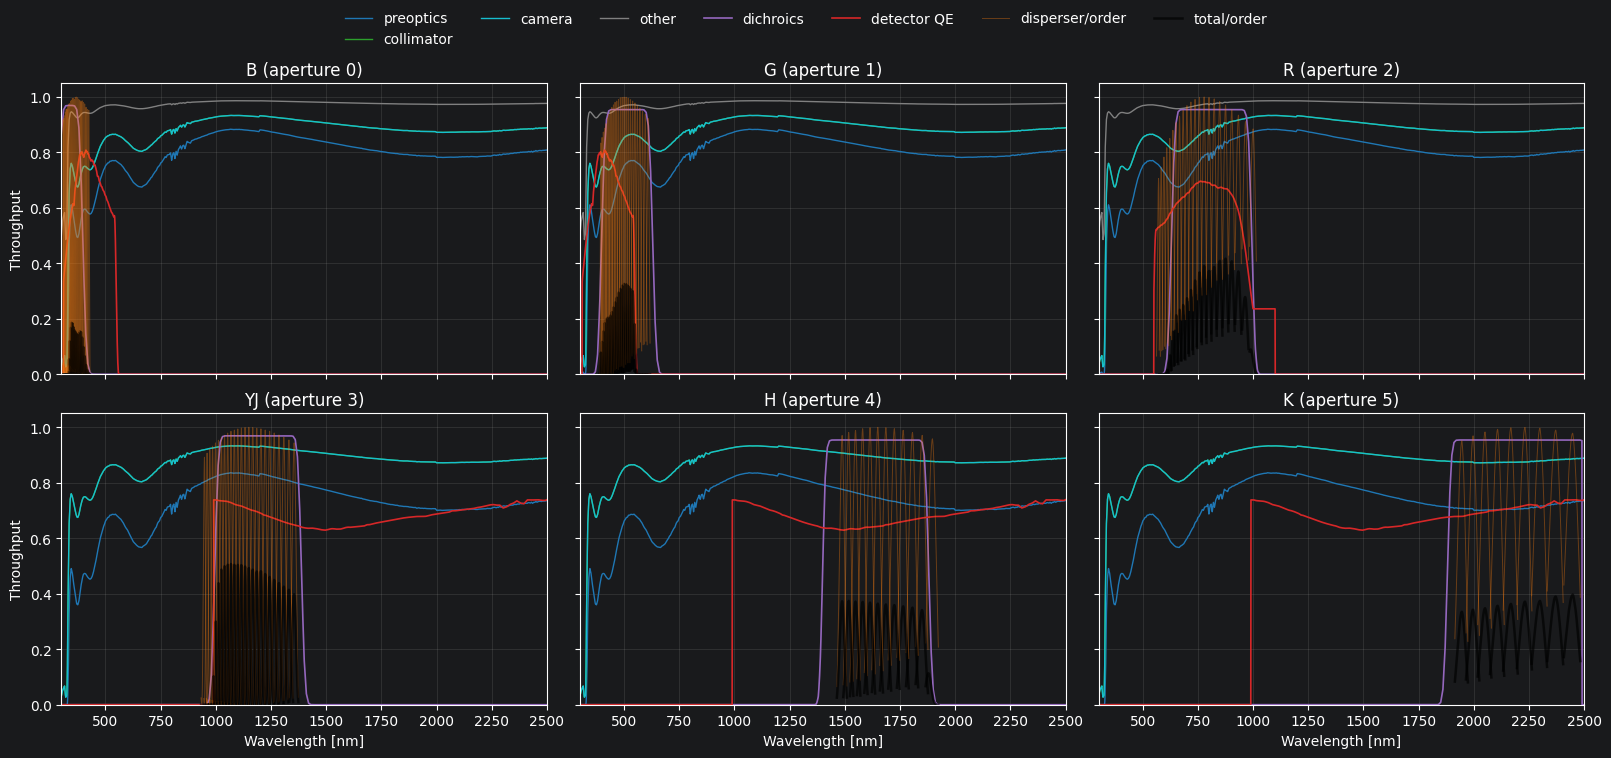

In [9]:
wave_nm = np.linspace(300, 2500, 5000) * u.nm
transmission_data = build_transmission_sanity_data(zs, wave_nm=wave_nm)
validate_transmission_sanity_data(transmission_data)
fig, axes = plot_transmission_sanity(transmission_data)


## Emissivity Check

This plot uses the active optical train and explicit `throughput_group` / `emission_phase` metadata from the ZShooter optics lists. Pre-disperser optics are shown as the terms that should still pass through trace mapping; post-disperser camera terms are shown after detector QE, which is the candidate diffuse image-plane background. Detector QE is plotted as throughput only, not as detector emissivity.


surface,group,action,temperature,emissivity_source,transmission_source,reflection_source,peak_output_emissivity,aperture_id,channel
str20,str10,str12,object,str26,str24,str26,float64,int64,str2
VIS_Fold,other,reflection,0,inferred from reflection,inferred from reflection,explicit,0.018867668207882535,0,B
VIS_PreOptFirst,preoptics,transmission,0,inferred from transmission,explicit,inferred from transmission,0.019887796517322243,0,B
VIS_ADC_12,preoptics,transmission,0,inferred from transmission,explicit,inferred from transmission,0.02102453391018346,0,B
VIS_ADC_34,preoptics,transmission,0,inferred from transmission,explicit,inferred from transmission,0.02229913716621199,0,B
VIS_Derotator_AR_1,preoptics,transmission,0,inferred from transmission,explicit,inferred from transmission,0.023738260886492557,0,B
VIS_Derotator_AR_2,preoptics,transmission,0,inferred from transmission,explicit,inferred from transmission,0.02537602616178766,0,B
VIS_Derotator_Refl_1,preoptics,reflection,0,inferred from reflection,inferred from reflection,explicit,0.027256476215346766,0,B
VIS_Derotator_Refl_2,preoptics,reflection,0,inferred from reflection,inferred from reflection,explicit,0.02943820156237265,0,B
VIS_Derotator_Refl_3,preoptics,reflection,0,inferred from reflection,inferred from reflection,explicit,0.031998930720169266,0,B


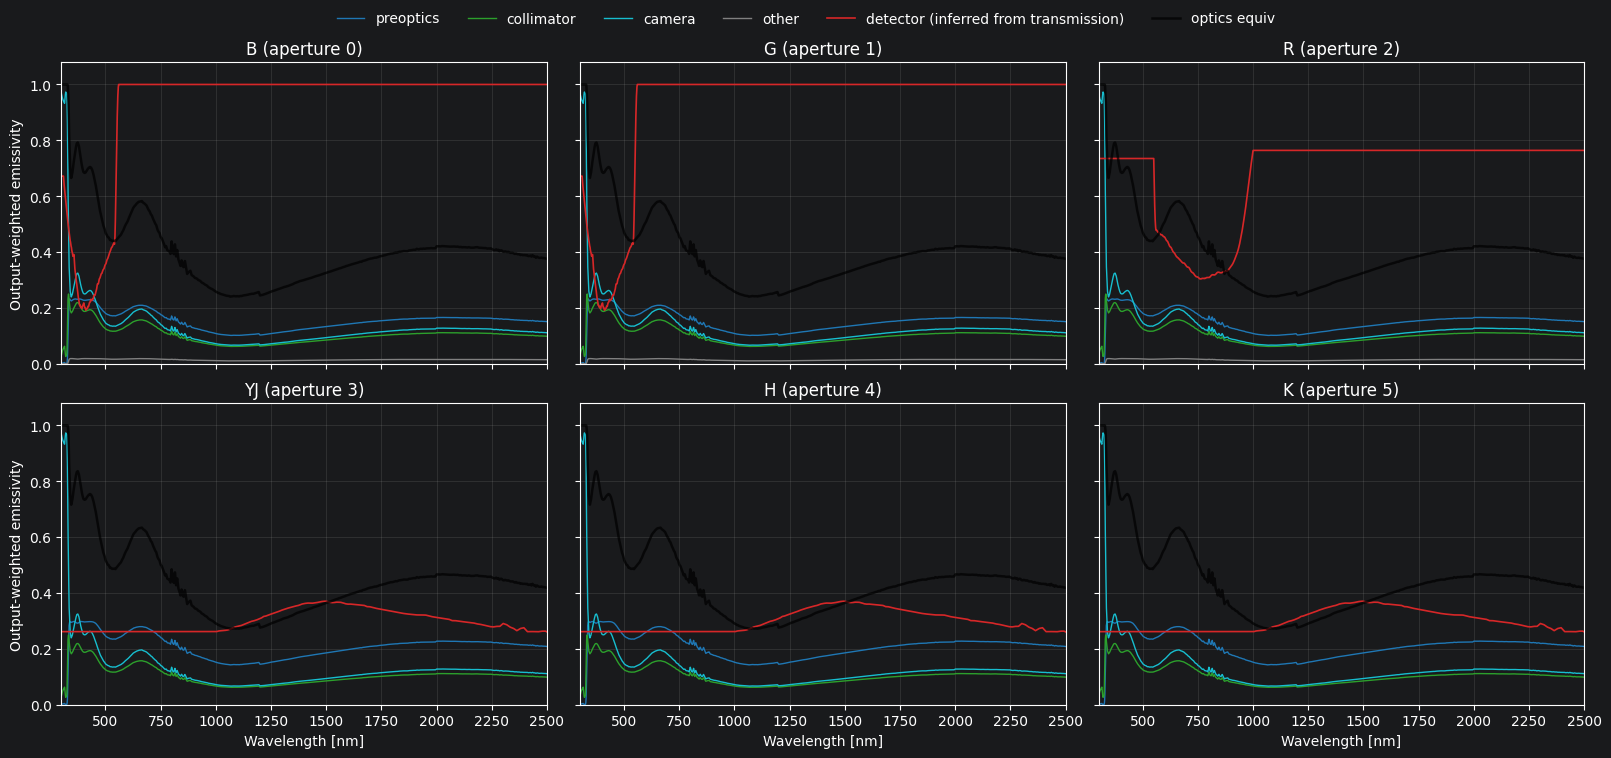

In [10]:
from zs_scopesim_tools.validation import (
    build_emissivity_sanity_data,
    plot_emissivity_sanity,
    validate_emissivity_sanity_data,
)

emissivity_data = build_emissivity_sanity_data(zs, wave_nm=wave_nm)
validate_emissivity_sanity_data(emissivity_data)
fig, axes = plot_emissivity_sanity(emissivity_data)
emissivity_data["details"]


## Detector Settings Sanity Check

In [11]:
detector_geometry = detector_geometry_table(zs)
detector_settings = detector_selector_matrix(zs)
display(detector_geometry)
display(detector_settings)


detector_id,image_plane_id,channel,detector,x_size,y_size,pixel_size_mm,gain_e_per_adu
int64,int64,str2,str6,int64,int64,float64,float64
0,0,B,CCD_B,2048,2048,0.015,1.0
1,1,G,CCD_G,2048,2048,0.015,1.0
2,2,R,CCD_R,2048,2048,0.015,1.0
3,3,YJ,APD_YJ,2048,2048,0.015,1.0
4,4,H,APD_H,2048,2048,0.015,1.0
5,5,K,APD_K,2048,2048,0.015,1.0


detector_id,channel,detector,selector,selector_key,selector_value,effect_class,settings
int64,str2,str6,str29,str11,int64,str19,str45
0,B,CCD_B,slitwheel_selector,aperture_id,0,SlitWheel,filename=None
0,B,CCD_B,channel_optics_selector,aperture_id,0,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat
0,B,CCD_B,detector_qe_selector,aperture_id,0,TERCurve,filename=detector_specs/CCD_B_TER.dat
0,B,CCD_B,exposure_integration_selector,detector_id,0,ExposureIntegration,"filename=None, dit=300.0, ndit=1"
0,B,CCD_B,dark_current_selector,detector_id,0,DarkCurrent,"filename=None, dit=300.0, ndit=1, value=1e-05"
0,B,CCD_B,readout_noise_selector,detector_id,0,BasicReadoutNoise,"filename=None, ndit=1, noise_std=0.1"
0,B,CCD_B,visible_binning_selector,detector_id,0,UnequalBinnedImage,"filename=None, binx=1, biny=1"
0,B,CCD_B,bias_selector,detector_id,0,Bias,"filename=None, bias=1040"
1,G,CCD_G,slitwheel_selector,aperture_id,1,SlitWheel,filename=None


Now look at the actual values for this configuration

In [12]:
# - Report total variance for est exposure time + binning + ndit and component proportion (%dark, %read) and anchor relative to sky in both a fiducial patch and with the current slit

## Sky Flux sanity check

In [13]:
cmd['!OBS.brightness'] = 'bright'    # Sky brightness (bright/gray/dark)

# TODO reinit whatever needs reiniting

In [14]:
# Load the effect instances for the different sky background components
# Get emission arrays for each component
wave_th, flux_th = fetch_effect_spectrum_or_transmission(zs, "atmo_transmission", "emission")
wave_cont, flux_cont = fetch_effect_spectrum_or_transmission(zs, "continuum_emission", "emission")
wave_line, flux_line = fetch_effect_spectrum_or_transmission(zs, "airglow_and_interline_continuum", "line_TER.emission")
wave_res, flux_res = fetch_effect_spectrum_or_transmission(zs, "airglow_and_interline_continuum", "continuum_TER.emission")

# simple resample all to a common wavelength grid for plotting
common_wave = np.linspace(0.3, 2.5, 10001) * u.um
from scipy.interpolate import CubicSpline
from synphot.units import convert_flux

flux_th_interp = CubicSpline(wave_th, flux_th)(common_wave)
flux_cont_interp = CubicSpline(wave_cont, flux_cont)(common_wave)
flux_line_interp = CubicSpline(wave_line, flux_line)(common_wave)
flux_res_interp = CubicSpline(wave_res, flux_res)(common_wave)

# convert to AB mag for plotting
flux_th_erg = convert_flux(wavelengths=common_wave, fluxes=flux_th_interp, out_flux_unit="abmag")
flux_cont_erg = convert_flux(wavelengths=common_wave, fluxes=flux_cont_interp, out_flux_unit="abmag")
flux_line_erg = convert_flux(wavelengths=common_wave, fluxes=flux_line_interp, out_flux_unit="abmag")
flux_res_erg = convert_flux(wavelengths=common_wave, fluxes=flux_res_interp, out_flux_unit="abmag")


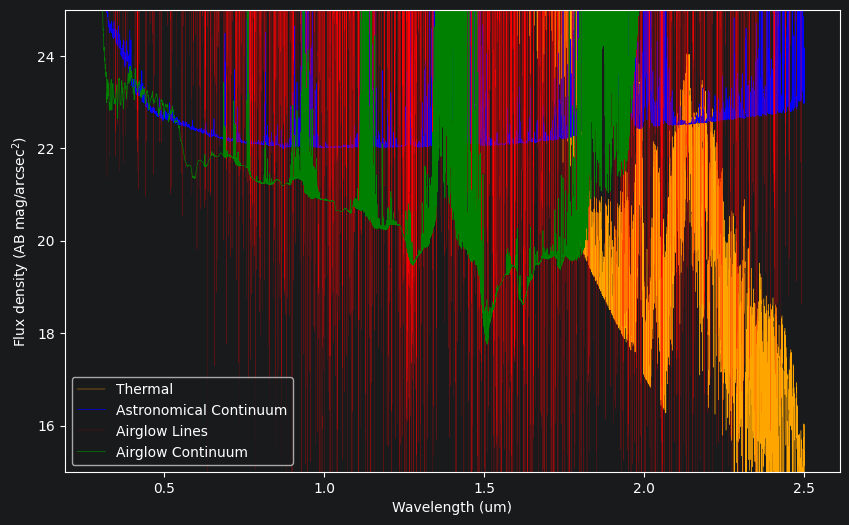

In [15]:
# plot
plt.figure(figsize=(10, 6))
plt.plot(common_wave, flux_th_erg, label='Thermal', color='orange', lw=0.3)
plt.plot(common_wave, flux_cont_erg, label='Astronomical Continuum', color='blue', lw=0.5)
plt.plot(common_wave, flux_line_erg, label='Airglow Lines', color='red', lw=0.1)
plt.plot(common_wave, flux_res_erg, label='Airglow Continuum', color='green', lw=0.5)
plt.xlabel("Wavelength (um)")
plt.ylabel(r"Flux density (AB mag/arcsec$^2$)")
plt.legend()
plt.ylim(15,25)
plt.show()

# Make and plot sources

(<Figure size 600x200 with 2 Axes>,
 array([[<Axes: title={'center': 'Spatial Profile'}>,
         <Axes: title={'center': 'Spectrum'}>]], dtype=object))

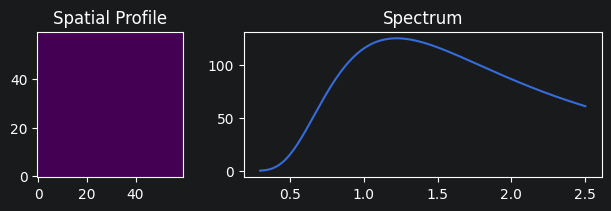

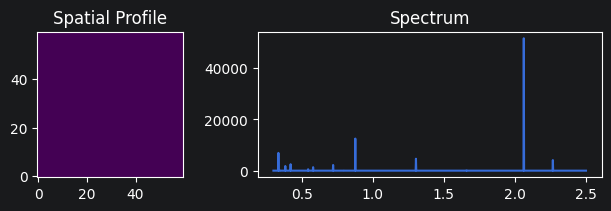

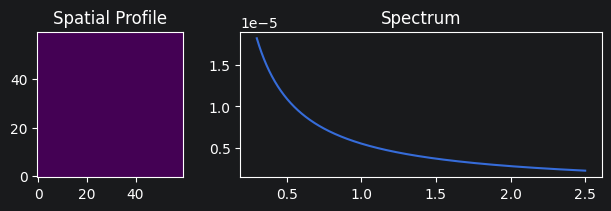

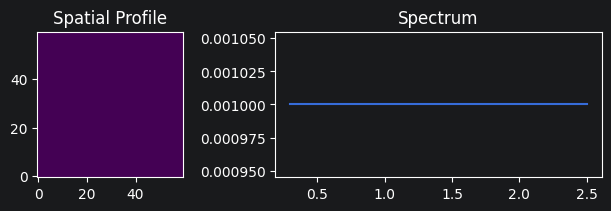

In [16]:
# Fetch a SN1a from spextra library
from spextra import Spextrum
from scopesim.source.source import Source

# SN1a point source
sn1a_source = Source(spectra=Spextrum('sne/sn1a').redshift(0.02).scale_to_magnitude(14*u.ABmag, 'g'), y=[2.5])

# Start point source
star_source = sim_tp.star('V', 23*u.ABmag, spec_type="A0V", x=[0], y=[0], library="pyckles")

# Calibration extended sources
quartz_flat = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=4*u.ABmag, filter_curve='V', extend=60)
plot_source(quartz_flat)

lamp_flat = lamp_flat()
plot_source(lamp_flat)

# Uniformly source with const AB mag
from scopesim.source.source_templates import ab_spectrum, uniform_source
uniform_flat_source = uniform_source(ab_spectrum(mag=20), extent=60)
plot_source(uniform_flat_source)

# Uniformly illuminated source with a const photon flux density of 1 photon/s/cm^2/Angstrom
from scopesim.source.source_templates import ConstFlux1D, SourceSpectrum, Empirical1D
waves = np.geomspace(100, 300000, 50000)
sp = ConstFlux1D(amplitude=0.001) # default unit is photon/s/cm^2/Angstrom, also takes units
flat2 = uniform_source(SourceSpectrum(Empirical1D, points=waves, lookup_table=sp(waves)), extent=60)
plot_source(flat2)


## Simulate it!

In [17]:
cmd['!OBS.airmass'] = 1.3            # Target coordinate information (other similar properties include: alt, az, ra, dec)
cmd['!OBS.seeing'] = 0.6            # Atmospheric seeing in arcsec (other similar properties include: pwv, humidity, temperature, pressure etc.)
cmd['!OBS.brightness'] = 'grey'    # Sky brightness (bright/gray/dark), !OBS.mjdobs takes precedence, call sky_band_prightness(<level>) to see what this means in band averages.
cmd['!OBS.dit'] = 300                 # Detector integration time in seconds for all detectors
cmd['!OBS.dit_green'] = 150                 # Detector integration time green channel, as demo
cmd['!OBS.ndit'] = 2                 # Number of exposures
cmd['!INST.vis_curr_slit'] = .7  # Slit width
cmd['!INST.nir_curr_slit'] = .7  # Slit width TODO change name

zs.observe(flat2) ## observes empty sky if no source is given

astar.scopesim.optics.fov_manager - Generating initial fovs_list.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, FoV setup
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 0
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 1
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 2
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 3
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 4
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 5
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 0 -> SlitWheel: "<empty> : [0.7]", volumes: 1
astar.scopesim.effects.apertures - Executing 0.7, FoV setup
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 1 -> SlitWheel: "<empty> : [0.7]", volumes: 1
astar.scopesim.effects.apertures - Executing 0.7, FoV setup
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 2 -> SlitWheel: "<

 FOVs:   0%|          | 0/120 [00:00<?, ?it/s]

astar.scopesim.optics.fov - 6 fields in FOV
astar.scopesim.optics.fov - old naxis: [60, 60]
astar.scopesim.optics.fov - Found 'deg' in image WCS, applying 360 fix.
astar.scopesim.optics.fov - XY HDU:
[[ 0.00833333 -0.00833333]
 [ 0.00833333  0.00833333]
 [-0.00833333  0.00833333]
 [-0.00833333 -0.00833333]]
astar.scopesim.optics.fov - XY FOV:
[[-1.40366430e-03 -8.00827423e-05]
 [-1.40366430e-03  9.72222222e-05]
 [ 1.38888889e-03  9.72222222e-05]
 [ 1.38888889e-03 -8.00827423e-05]]
astar.scopesim.optics.fov - xy0s: [-1.40366430e-03 -8.00827423e-05]; xy1s: [1.38888889e-03 9.72222222e-05]
astar.scopesim.optics.fov - xyp:
[[34.5531915 29.2117021]
 [24.5       29.85     ]]
astar.scopesim.optics.fov - xyp:
[[24.5       29.2117021]
 [34.5531915 29.85     ]]
astar.scopesim.optics.fov - xy0p: [24 29]; xy1p: [35 30]
astar.scopesim.optics.fov - xy0p: [24 29]; xy1p: [35 30]


 FOV effects:   0%|          | 0/7 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.analytical - WARNING: Kernel size too small, kernel sums to 0.9767626382005072
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is 179.
astar.scopesim.effects.ter_curves - Executin

...

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is 179.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to Fiel

 FOV effects:   0%|          | 0/7 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is 179.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to Fiel

 FOV effects:   0%|          | 0/7 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is 179.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to Fiel

#### Read it out

In [18]:
hdul = zs.readout()

astar.scopesim.optics.optical_train - exptime: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - dit: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - ndit: None given in kwargs, put in !OBS
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.electronic - ExposureIntegration.: DIT = 300.0 s, NDIT = 1
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, s

## Show it

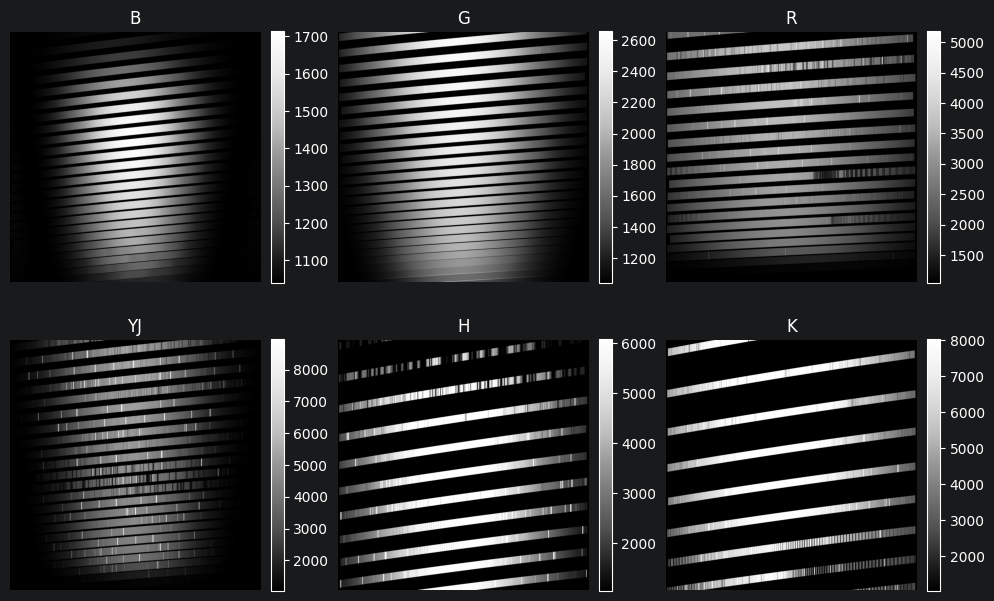

In [19]:
from astropy.visualization import ZScaleInterval

# reduce space between subplots
fig, axes = plt.subplots(2,3, figsize=(12,8), gridspec_kw={'wspace':0.2}, tight_layout=True)
titles = ['B', 'G', 'R', 'YJ', 'H', 'K']
for i, (ax, imhdu) in enumerate(zip(axes.flat, hdul)):
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(imhdu[1].data)
    ax.axis("off")
    im = ax.imshow(imhdu[1].data, origin='lower', vmin=vmin, vmax=vmax, cmap='Grays_r')
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.subplots_adjust(wspace=0.0, hspace=0.0)
fig.savefig(output_dir / "zspec_echellogram.png", dpi=300)

for title, channel_hdul in zip(titles, hdul):
    channel_hdul.writeto(output_dir / f"zspec_{title}.fits", overwrite=True)
